# demos.shallow_kipf_welling_gnn

This notebook demonstrates a minimal classical graph neural network (GNN) applied to power grid scenarios using the Kipf-Welling graph convolution approach. In particular,  it builds a small pandapower network (a low-voltage or medium-voltage test grid) consisting of buses (nodes), lines (connections between nodes), and loads (active and reactive power consumption at buses) with the goal of predicting node voltage magnitudes from load and generation features using a two-layer classical GNN. 

In [1]:
import os
os.chdir("..")

In [2]:
import numpy as np
import pandapower as pp
import pandas as pd
from utils.graphs import build_graph_input
from utils.pandapower_adapter import *
from classical_gnns.shallow_kipf_welling_gnn import *

In [3]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

## Utilities

In [4]:
def generate_voltage_dataset(base_net, n_samples=200, seed=42):
    """
    Generate node-level regression data on a fixed pandapower topology.

    Args:
        base_net: Base pandapower network.
        n_samples: Number of operating scenarios.
        seed: Random seed.

    Returns:
        X: Input array of shape (num_samples, num_nodes, 1).
        Y: Target array of shape (num_samples, num_nodes, 1).
    """
    rng = np.random.default_rng(seed)
    X_list = []
    Y_list = []
    for _ in range(n_samples):
        net = copy.deepcopy(base_net)
        for load_idx in net.load.index:
            p = rng.uniform(0.2, 1.2)
            q = 0.2 * p
            net.load.loc[load_idx, "p_mw"] = p
            net.load.loc[load_idx, "q_mvar"] = q
        pp.runpp(net)
        node_order = list(map(int, net.bus.index))
        x = np.zeros((len(node_order), 1), dtype=np.float32)
        for _, row in net.load.iterrows():
            bus_idx = int(row["bus"])
            x[bus_idx, 0] += float(row["p_mw"])
        y = net.res_bus.loc[node_order, "vm_pu"].to_numpy(dtype=np.float32).reshape(-1, 1)
        X_list.append(x)
        Y_list.append(y)

    X = np.stack(X_list, axis=0)
    Y = np.stack(Y_list, axis=0)
    return X, Y

In [5]:
class TorchTwoLayerKipfWellingGNN(nn.Module):
    """
    Trainable two-layer Kipf-Welling GNN using GraphInput for graph operators.

    The graph structure is stored in graph_input.
    The batch of node features is passed at call time.
    """

    def __init__(self, graph_input, in_features=1, hidden_features=16, out_features=1):
        super().__init__()
        self.graph_input = graph_input
        self.lin1 = nn.Linear(in_features, hidden_features)
        self.lin2 = nn.Linear(hidden_features, out_features)
        a_hat = graph_input.kipf_welling_adjacency().astype(np.float32)
        self.register_buffer("a_hat", torch.tensor(a_hat, dtype=torch.float32))

    def forward(self, x):
        """
        Args:
            x: Tensor of shape (batch, num_nodes, in_features).

        Returns:
            Tensor of shape (batch, num_nodes, out_features).
        """
        h = torch.matmul(self.a_hat, x)
        h = self.lin1(h)
        h = torch.relu(h)
        h = torch.matmul(self.a_hat, h)
        h = self.lin2(h)
        return h

## Test grid and dataset

In [6]:
# Pandapower demo network
base_net = pp.create_empty_network(sn_mva=100.0)
buses = [pp.create_bus(base_net, vn_kv=20.0, name=f"Bus {i}") for i in range(5)]
pp.create_ext_grid(base_net, bus=buses[0], vm_pu=1.0)
for b in buses[1:]:
    pp.create_load(base_net, bus=b, p_mw=0.5, q_mvar=0.1)
line_kwargs = dict(length_km=1.0,r_ohm_per_km=0.25,x_ohm_per_km=0.10,
                   c_nf_per_km=10.0,max_i_ka=0.40,)
for i in range(4):
    pp.create_line_from_parameters(base_net, buses[i], buses[i + 1], **line_kwargs)

In [7]:
# Dataset generation
X, Y = generate_voltage_dataset(base_net, n_samples=300, seed=42)
#print("X shape:", X.shape)
#print("Y shape:", Y.shape)

In [8]:
# A dedicated bundle for later visualizations
demo_net = copy.deepcopy(base_net)
for load_idx in demo_net.load.index:
    demo_net.load.loc[load_idx, "p_mw"] = 0.3 + 0.2 * load_idx
    demo_net.load.loc[load_idx, "q_mvar"] = 0.2 * demo_net.load.loc[load_idx, "p_mw"]
bundle = pandapower_to_graph_bundle(demo_net,node_feature_specs=["load_p_mw"],
                                    edge_feature_specs=["loading_percent"],run_powerflow=True,)
graph_input = bundle_to_graph_input(bundle,build_graph_input_fn=build_graph_input,)


## Kipf-Welling layers

In [9]:
W1 = build_random_weight(in_features=1, out_features=8, seed=42)
W2 = build_random_weight(in_features=8, out_features=1, seed=43)
baseline_output_np = two_layer_kipf_welling(graph_input=graph_input,weight_1=W1,weight_2=W2,
                                hidden_activation=relu,output_activation=identity,)
#print("Output shape:", baseline_output_np.shape)
#print("Output:", baseline_output_np)

## Train and test

In [10]:
# Train-test split
n_samples = X.shape[0]
n_train = int(0.8 * n_samples)
X_train = torch.tensor(X[:n_train], dtype=torch.float32)
Y_train = torch.tensor(Y[:n_train], dtype=torch.float32)
X_test = torch.tensor(X[n_train:], dtype=torch.float32)
Y_test = torch.tensor(Y[n_train:], dtype=torch.float32)
#print("Train X:", X_train.shape)
#print("Train Y:", Y_train.shape)
#print("Test X :", X_test.shape)
#print("Test Y :", Y_test.shape)

In [11]:
# Model
model = TorchTwoLayerKipfWellingGNN(graph_input=graph_input,in_features=1,
                                    hidden_features=16,out_features=1,)
#print(model)

In [12]:
# Training loop
optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()
n_epochs = 400
train_losses = []
test_losses = []
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    pred_train = model(X_train)
    loss_train = loss_fn(pred_train, Y_train)
    loss_train.backward()
    optimizer.step()
    model.eval()
    with torch.no_grad():
        pred_test = model(X_test)
        loss_test = loss_fn(pred_test, Y_test)
    train_losses.append(loss_train.item())
    test_losses.append(loss_test.item())
    #if epoch % 50 == 0 or epoch == n_epochs - 1:
    #    print(f"Epoch {epoch:03d} | "f"train loss = {loss_train.item():.6e} | "f"test loss = {loss_test.item():.6e}")

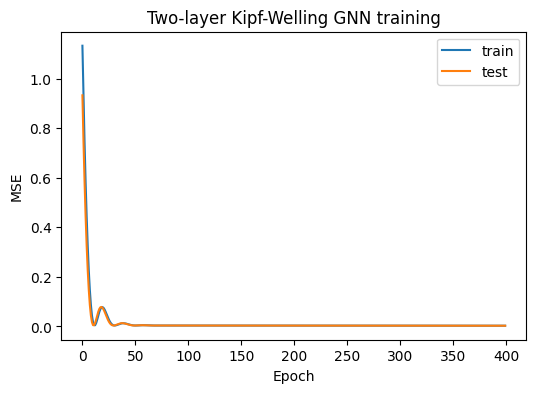

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Two-layer Kipf-Welling GNN training")
plt.legend()
plt.show()

In [14]:
#Evaluate 
model.eval()
with torch.no_grad():
    pred_test = model(X_test)

pred_test_np = pred_test.cpu().numpy()
y_test_np = Y_test.cpu().numpy()
mae = np.mean(np.abs(pred_test_np - y_test_np))
rmse = np.sqrt(np.mean((pred_test_np - y_test_np) ** 2))
ss_res = np.sum((y_test_np - pred_test_np) ** 2)
ss_tot = np.sum((y_test_np - np.mean(y_test_np)) ** 2)
r2 = 1.0 - ss_res / ss_tot
metrics_df = pd.DataFrame(
    {
        "metric": ["MAE", "RMSE", "R2"],
        "value": [mae, rmse, r2],
    }
)
metrics_df

,metric,value
0,MAE,0.047709
1,RMSE,0.053077
2,R2,-773.061340


## True vs predicted (one sample)

In [15]:
# Inspect test scenario
sample_idx = 0
x_sample = X_test[sample_idx].cpu().numpy().reshape(-1)
y_true = Y_test[sample_idx].cpu().numpy().reshape(-1)
y_pred = pred_test_np[sample_idx].reshape(-1)
#print("Input load_p_mw:")
#print(x_sample)
#print("\nTrue vm_pu:")
#print(y_true)
#print("\nPredicted vm_pu:")
#print(y_pred)

In [16]:
display_net = copy.deepcopy(base_net)
test_sample_global_idx = n_train + sample_idx
sample_loads = X[test_sample_global_idx, :, 0]

for load_idx, bus_idx in zip(display_net.load.index, display_net.load["bus"].to_numpy()):
    bus_idx = int(bus_idx)
    if bus_idx == 0:
        continue
    p = float(sample_loads[bus_idx])
    display_net.load.loc[load_idx, "p_mw"] = p
    display_net.load.loc[load_idx, "q_mvar"] = 0.2 * p

display_bundle = pandapower_to_graph_bundle(display_net,node_feature_specs=["load_p_mw"],
                                            edge_feature_specs=["loading_percent"],run_powerflow=True,)
#display_pandapower_bundle(bundle=display_bundle,input_node_feature_index=0,
#                          output_node_values=y_pred,edge_feature_index=0,layout="line",figsize=(15.0, 4.0),)

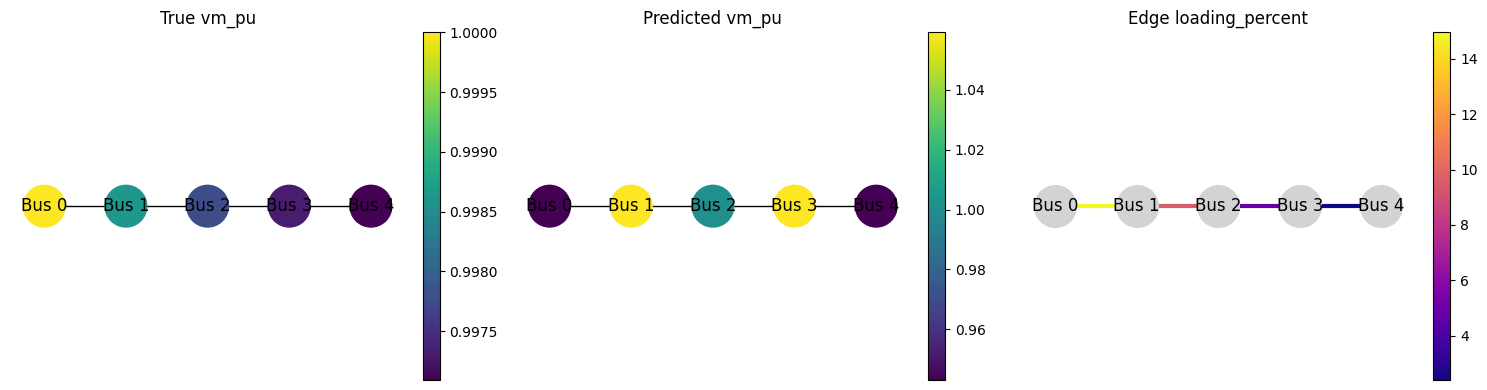

In [17]:
# Compare true vs predicted
edge_values = np.asarray(
    [display_bundle.edge_features[tuple(sorted((u, v)))][0] for u, v in display_bundle.graph.edges()],
    dtype=float,)

display_graph_signal_comparison(G=display_bundle.graph,node_order=display_bundle.node_order,
                                input_node_values=y_true,output_node_values=y_pred,edge_values=edge_values,
                                node_labels=display_bundle.node_labels,layout="line",input_title="True vm_pu",
                                output_title="Predicted vm_pu",edge_title="Edge loading_percent",figsize=(15.0, 4.0),)

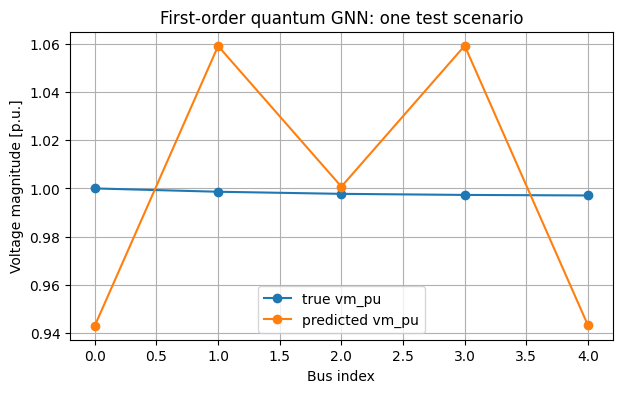

In [18]:
plt.figure(figsize=(7, 4))
plt.plot(display_bundle.node_order, y_true, marker="o", label="true vm_pu")
plt.plot(display_bundle.node_order, y_pred, marker="o", label="predicted vm_pu")
plt.xlabel("Bus index")
plt.ylabel("Voltage magnitude [p.u.]")
plt.title("First-order quantum GNN: one test scenario")
plt.grid(True)
plt.legend()
plt.show()